In [92]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
f = lambda x: x**2 * np.exp(x)

In [54]:
xs = np.linspace(0., 10., 1001)

In [55]:
np.sum(f(xs) * 10/1001)

np.float64(1815388.066420146)

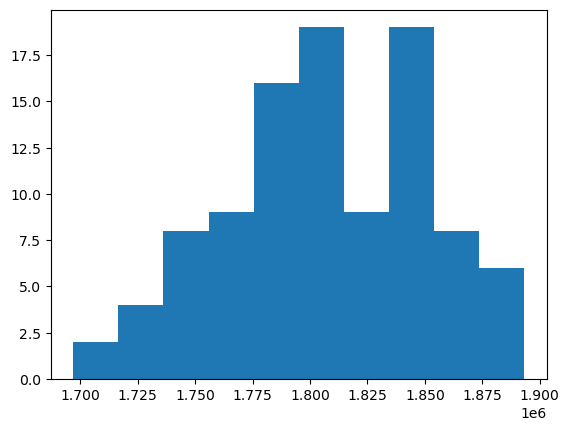

In [93]:
l_simple = []
for _ in range(100):
    Us = np.random.uniform(0, 1, 10000)
    l_simple.append(1000 * np.mean(Us**2 * np.exp(10. * Us)))
plt.hist(l_simple)
plt.show()

Variables antithétiques

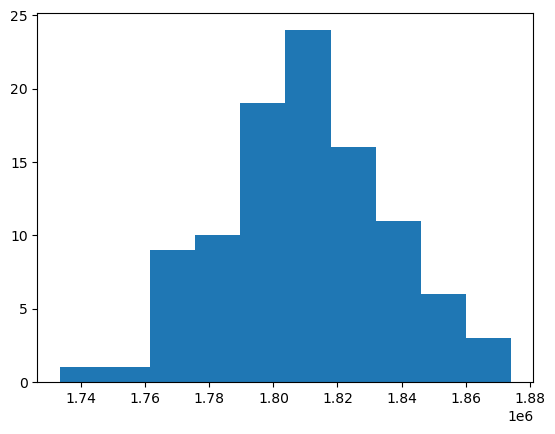

In [94]:
l_anti = []
for _ in range(100):
    Us = np.random.uniform(0, 1, 10000)
    Vs = 1-Us
    l_anti.append(500 * np.mean(Us**2 * np.exp(10. * Us) + Vs**2 * np.exp(10. * Vs)))
plt.hist(l_anti)
plt.show()

In [124]:
def payoff_call(K):
    def g(S):
        return np.maximum(S - K, 0)
    return g

In [140]:
def MCBS_euro(S_0, r, sigma, T, payoff, nb_MC=10000):
    WTs = np.sqrt(T) * np.random.normal(0, 1, nb_MC)
    STs = S_0 * np.exp((r-0.5*sigma**2)*T+sigma*WTs)
    return np.exp(-r*T) * np.mean(payoff(STs))

def MCBS_euro_anti(S_0, r, sigma, T, payoff, nb_MC=10000):
    WTs = np.sqrt(T) * np.random.normal(0, 1, nb_MC)
    STs = S_0 * np.exp((r-0.5*sigma**2)*T+sigma*WTs)
    STs_anti = S_0 * np.exp((r-0.5*sigma**2)*T-sigma*WTs)
    return 0.5*np.exp(-r*T) * (np.mean(payoff(STs)) + np.mean(payoff(STs_anti)))

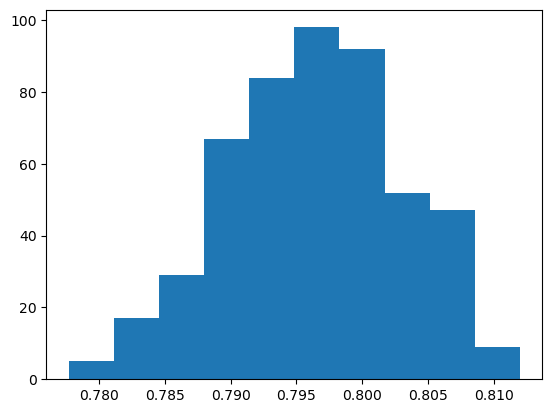

In [139]:
l_basic = []
for _ in range(500):
    l_basic.append(MCBS_euro(10, 0, 0.2, 1., payoff_call(10), 40000))
plt.hist(l_basic)
plt.show()

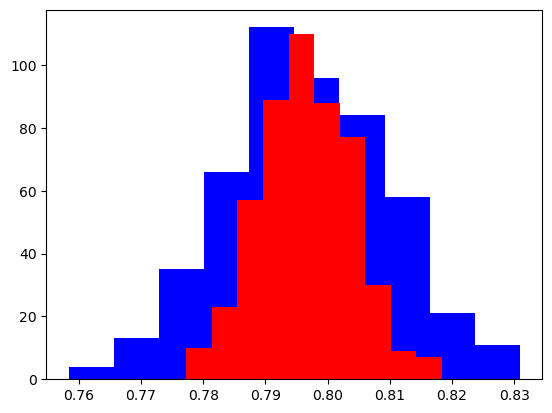

In [147]:
l_basic = []
l_anti = []
for _ in range(500):
    l_basic.append(MCBS_euro(10, 0, 0.2, 1., payoff_call(10)))
    l_anti.append(MCBS_euro_anti(10, 0, 0.2, 1., payoff_call(10)))
plt.hist(l_basic, color='b')
plt.hist(l_anti, color='r')
plt.show()

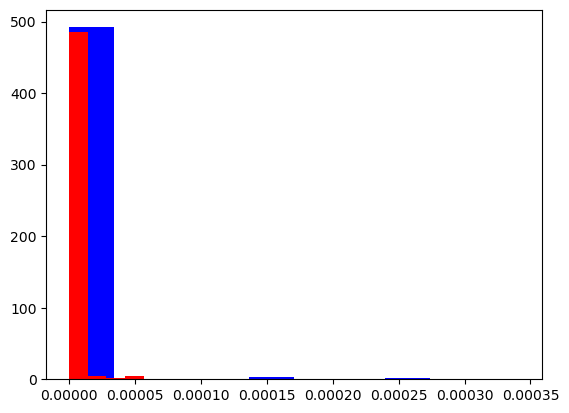

In [149]:
l_basic = []
l_anti = []
for _ in range(500):
    l_basic.append(MCBS_euro(10, 0, 0.2, 1., payoff_call(25)))
    l_anti.append(MCBS_euro_anti(10, 0, 0.2, 1., payoff_call(25)))
plt.hist(l_basic, color='b')
plt.hist(l_anti, color='r')
plt.show()

In [153]:
np.mean(np.array(l_anti) == 0.)

np.float64(0.962)

In [200]:
def MCBS_euro_IS(S_0, r, sigma, T, payoff, alpha, nb_MC=10000):
    WTs = np.sqrt(T) * np.random.normal(0, 1, nb_MC)
    STs = S_0 * np.exp((alpha-0.5*sigma**2)*T+sigma*WTs)
    return np.exp(-r*T) * np.mean(payoff(STs) * np.exp(-(alpha-r)/sigma * WTs -0.5 * ((alpha-r)/sigma)**2 * T))

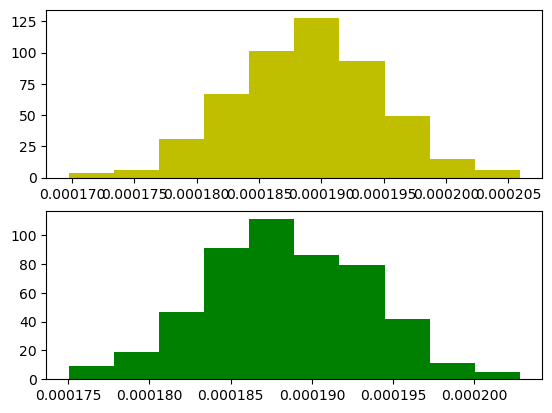

In [203]:
l_basic = []
l_IS = []
l_IS_anti = []
for _ in range(500):
    l_basic.append(MCBS_euro(10, 0, 0.2, 1., payoff_call(20), nb_MC=10_000_000))
    l_IS.append(MCBS_euro_IS(10, 0, 0.2, 1., payoff_call(20), alpha=0.5, nb_MC=10000))
fig,axs = plt.subplots(2)
axs[0].hist(l_basic, color='y')
axs[1].hist(l_IS, color='g')
plt.show()

In [196]:
S0=10
K=20
r=0
sigma=0.2
T=1
from scipy.stats import norm
d1 = (np.log(S0 / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
d2 = d1 - sigma * np.sqrt(T)
S0 * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)


np.float64(0.0001886218176150034)

In [220]:
def MCBS_PDI(S_0, r, sigma, T, K, B, nb_MC=10000):
    Wts = np.concat([np.zeros((nb_MC,1)),np.cumsum(np.sqrt(T/1000) * np.random.normal(0, 1, [nb_MC,1000]), axis=1)], axis=1)
    StS = S_0 * np.exp((r-0.5*sigma**2)*T+sigma*Wts)
    minSs = np.min(StS, axis = 1)
    payoffs = np.maximum(K-StS[:,-1], 0.) * (minSs <= B)
    return np.exp(-r*T) * np.mean(payoffs)

In [223]:
MCBS_PDI(10, 0, 0.2, 1., 10, 6)

np.float64(0.05505530574169127)

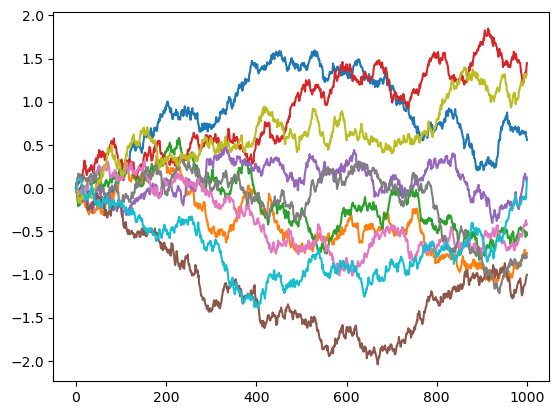

In [215]:
T=1
nb_MC=10
plt.plot(np.concat([np.zeros((nb_MC,1)),np.cumsum(np.sqrt(T/1000) * np.random.normal(0, 1, [nb_MC,1000]), axis=1)], axis=1).T)
plt.show()

In [217]:
nb_MC = 10
Wts = np.concat([np.zeros((nb_MC,1)),np.cumsum(np.sqrt(T/1000) * np.random.normal(0, 1, [nb_MC,1000]), axis=1)], axis=1)
StS = S0 * np.exp((r-0.5*sigma**2)*T+sigma*Wts)
np.min(StS, axis = 1)

array([9.23856345, 9.21554695, 8.22104662, 9.66800784, 8.90131591,
       9.68756165, 6.19066883, 7.76118171, 8.02836121, 8.32953313])